In [1]:
import numpy as np
import pandas as pd
from gensim.models import Word2Vec
import random
from scipy.spatial.distance import cosine
from tqdm import tqdm

df = pd.read_csv("/Users/cheywakeland-hart/Desktop/playlist_pred/data/playlist_subset/playlist_subset_1.csv")
df["track_id"] = df["track_name"] + " - " + df["artist_name"]

playlist_sequences = df.groupby("pid")["track_id"].apply(list).tolist()


In [2]:

model = Word2Vec(sentences=playlist_sequences,
                 vector_size=100,
                 window=8,
                 min_count=5,
                 workers=4,
                 sg=1)

all_song_ids = set(model.wv.index_to_key)
results = []

# Go through each playlist sewparately
for pid, group in tqdm(df.groupby("pid"), desc="Evaluating playlists"):
    track_ids = group["track_id"].tolist()
    
    if len(track_ids) < 5:
        continue

    # 75/25 split
    sample_size = int(len(track_ids) * 0.75)
    sampled = random.sample(track_ids, sample_size)
    held_out = [song for song in track_ids if song not in sampled]

    # Get single playlist vector
    vectors = [model.wv[song] for song in sampled if song in model.wv]
    if not vectors:
        continue

    playlist_vec = np.mean(vectors, axis=0)

    # cosine similarity
    sim_scores = []
    for song in all_song_ids:
        sim = 1 - cosine(playlist_vec, model.wv[song])
        sim_scores.append((song, sim))

   
    sim_scores.sort(key=lambda x: x[1], reverse=True)
    top_5 = [s for s, _ in sim_scores[:5]]
    hits = sum([1 for s in top_5 if s in held_out])

    results.append({
        "pid": pid,
        "n_total": len(track_ids),
        "n_sampled": len(sampled),
        "n_held_out": len(held_out),
        "hits_in_top_5": hits
    })


Evaluating playlists: 100%|█████████████████| 5000/5000 [05:29<00:00, 15.19it/s]


In [4]:
results_df = pd.DataFrame(results)
n_with_hits = (results_df["hits_in_top_5"] >= 1).sum()
n_total = len(results_df)
prop_with_hits = n_with_hits / n_total


print(f"✅ Playlists with at least 1 correct song in top 5: {n_with_hits}/{n_total} ({prop_with_hits:.2%})")


✅ Playlists with at least 1 correct song in top 5: 469/4810 (9.75%)


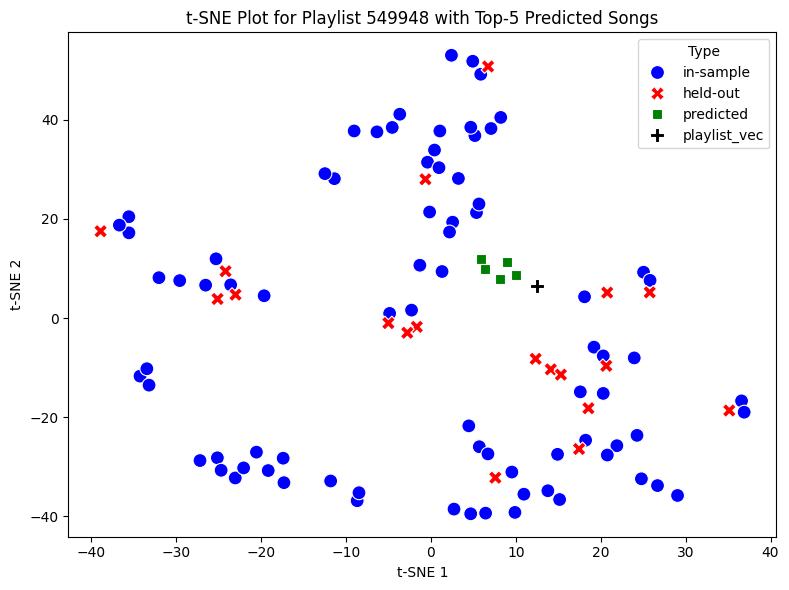

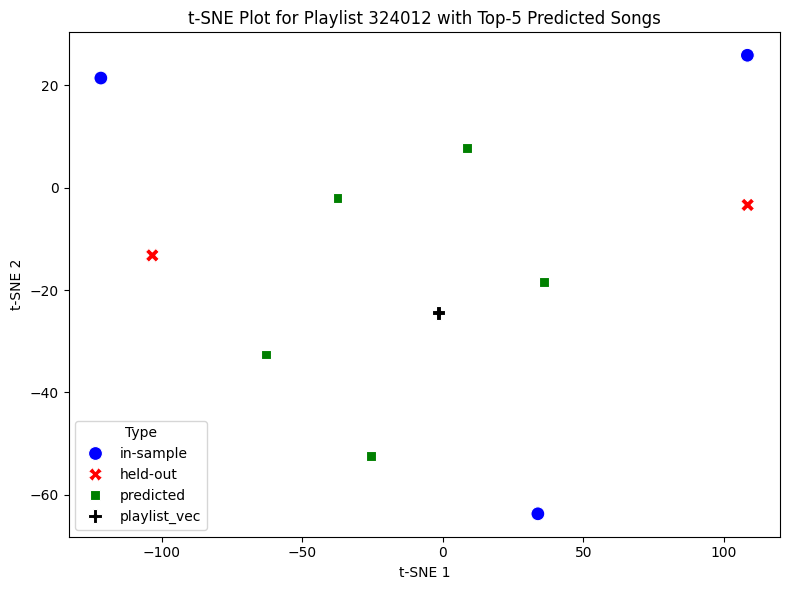

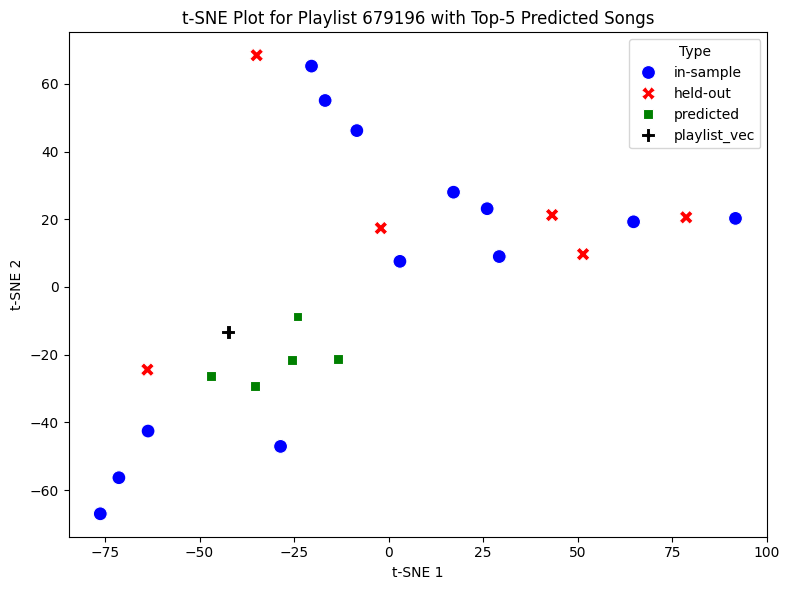

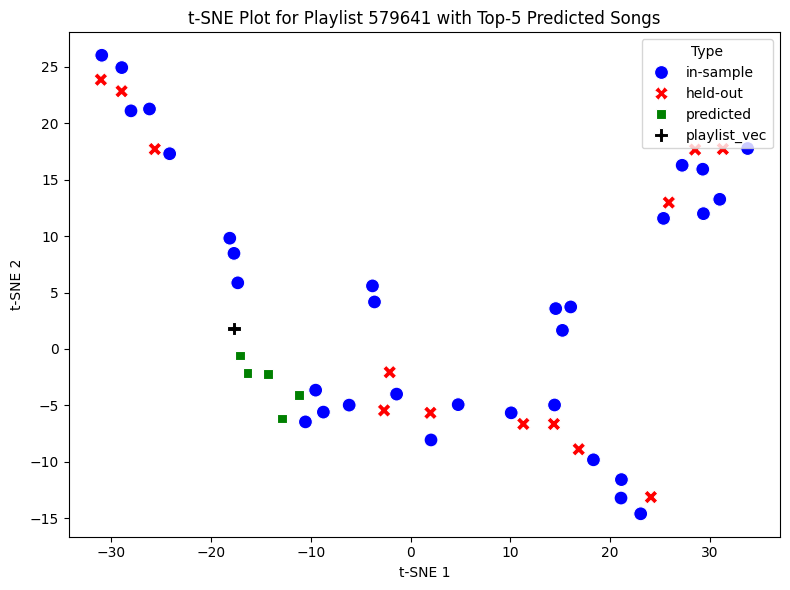

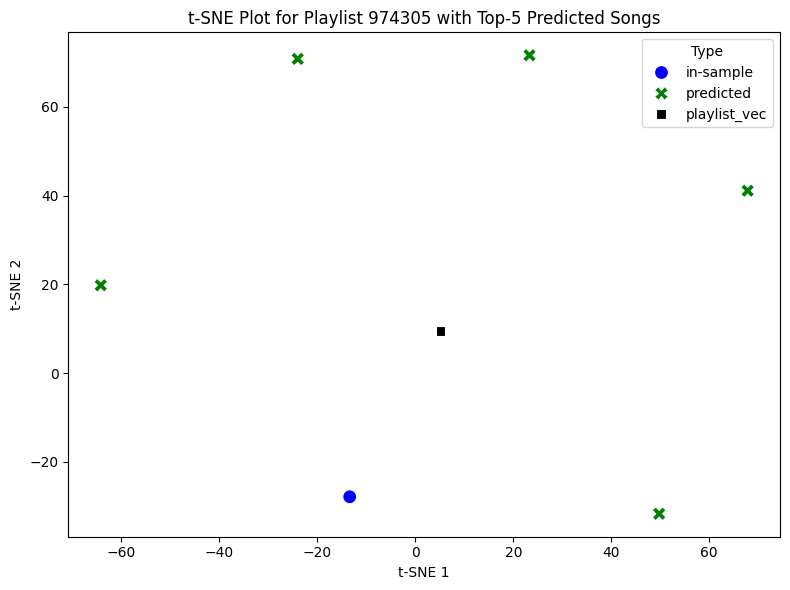

In [8]:
from sklearn.manifold import TSNE
from scipy.spatial.distance import cosine

for pid in example_pids:
    track_ids = df[df["pid"] == pid]["track_id"].tolist()
    if len(track_ids) < 5:
        continue

    sample_size = int(len(track_ids) * 0.75)
    sampled = random.sample(track_ids, sample_size)
    held_out = [s for s in track_ids if s not in sampled]

    # Build playlist vector
    sampled_vectors = [model.wv[s] for s in sampled if s in model.wv]
    if not sampled_vectors:
        continue

    playlist_vec = np.mean(sampled_vectors, axis=0)

    # Top 5 most similar songs from full vocabulary
    all_song_ids = model.wv.index_to_key
    sim_scores = []
    for s in all_song_ids:
        if s not in sampled:  # avoid using training songs
            sim = 1 - cosine(playlist_vec, model.wv[s])
            sim_scores.append((s, sim))
    top_preds = [s for s, _ in sorted(sim_scores, key=lambda x: x[1], reverse=True)[:5]]

    # Build data for tsne: sampled, held-out, predictions, playlist_vec
    data_points = []

    for s in sampled:
        if s in model.wv:
            data_points.append({"song": s, "type": "in-sample", "vec": model.wv[s]})

    for s in held_out:
        if s in model.wv:
            data_points.append({"song": s, "type": "held-out", "vec": model.wv[s]})

    for s in top_preds:
        if s in model.wv:
            data_points.append({"song": s, "type": "predicted", "vec": model.wv[s]})

    # Add playlist vector
    data_points.append({"song": "playlist_center", "type": "playlist_vec", "vec": playlist_vec})

    # Run t-SNE
    vec_matrix = np.array([d["vec"] for d in data_points])
    tsne = TSNE(n_components=2, random_state=42, perplexity=5)
    vec_2d = tsne.fit_transform(vec_matrix)

    # Build DataFrame for plotting
    plot_df = pd.DataFrame({
        "song": [d["song"] for d in data_points],
        "type": [d["type"] for d in data_points],
        "x": vec_2d[:, 0],
        "y": vec_2d[:, 1]
    })

    # Plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=plot_df,
        x="x", y="y",
        hue="type", style="type", s=100,
        palette={
            "in-sample": "blue",
            "held-out": "red",
            "predicted": "green",
            "playlist_vec": "black"
        }
    )
    plt.title(f"t-SNE Plot for Playlist {pid} with Top-5 Predicted Songs")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.legend(title="Type")
    plt.tight_layout()
    plt.show()



In [28]:
from sklearn.cluster import KMeans
from scipy.spatial.distance import cosine
import numpy as np
def predict_with_kmeans(pid, df, model, n_clusters=3, topn=5, return_plot_data=False):
    track_ids = df[df["pid"] == pid]["track_id"].tolist()
    if len(track_ids) < n_clusters + 2:
        return None

    sample_size = int(len(track_ids) * 0.75)
    sampled = random.sample(track_ids, sample_size)
    held_out = [s for s in track_ids if s not in sampled]

    sampled_vecs = [model.wv[s] for s in sampled if s in model.wv]
    if len(sampled_vecs) < n_clusters:
        return None

    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    kmeans.fit(sampled_vecs)
    centers = kmeans.cluster_centers_

    top_preds = []
    N = 2  # number of predictions per cluster

    for i, center in enumerate(centers):
        cluster_predictions = []
        for s in model.wv.index_to_key:
            if s in sampled:
                continue
            vec = model.wv[s]
            sim = 1 - cosine(vec, center)
            cluster_predictions.append((s, sim))
        top_N = sorted(cluster_predictions, key=lambda x: x[1], reverse=True)[:N]
        top_preds.extend(top_N)

    predicted_songs = [s for s, _ in top_preds]

    hits = sum([1 for s in predicted_songs if s in held_out])

    result = {
        "pid": pid,
        "n_held_out": len(held_out),
        "hits_in_topn": hits,
        "top_predictions": predicted_songs,
        "held_out_songs": held_out
    }

    if return_plot_data:
        data_points = []
        for s in sampled:
            if s in model.wv:
                data_points.append({"song": s, "type": "in-sample", "vec": model.wv[s]})
        for s in held_out:
            if s in model.wv:
                data_points.append({"song": s, "type": "held-out", "vec": model.wv[s]})
        for s in predicted_songs:
            if s in model.wv:
                data_points.append({"song": s, "type": "predicted", "vec": model.wv[s]})
        return result, data_points, centers

    return result


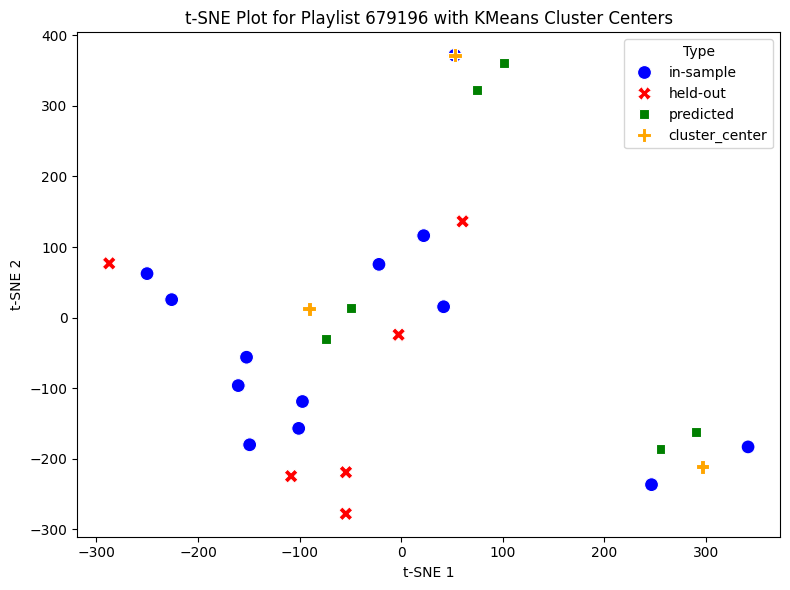

In [29]:

pid = 679196
result, data_points, centers = predict_with_kmeans(pid, df, model, return_plot_data=True)


vec_matrix = np.array([d["vec"] for d in data_points] + list(centers))
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
vec_2d = tsne.fit_transform(vec_matrix)


for i, c in enumerate(centers):
    data_points.append({"song": f"cluster_center_{i}", "type": "cluster_center", "vec": c})


plot_df = pd.DataFrame({
    "song": [d["song"] for d in data_points],
    "type": [d["type"] for d in data_points],
    "x": vec_2d[:, 0],
    "y": vec_2d[:, 1]
})


plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=plot_df,
    x="x", y="y",
    hue="type", style="type", s=100,
    palette={
        "in-sample": "blue",
        "held-out": "red",
        "predicted": "green",
        "cluster_center": "orange"
    }
)
plt.title(f"t-SNE Plot for Playlist {pid} with KMeans Cluster Centers")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Type")
plt.tight_layout()
plt.show()

